# Tempotron at the critical working point: train from spikes

This demo loads real spiking data, groups spikes by neuron, trains the original Tempotron and evaluates held-out trials. No pre-trained weights or stored accuracy are used as inputs.

- Coupled heterogeneous network, realization 0, **LBI index 10, g_EI_scale = 1.0895**, matching the Figure 3C operating point; inhibitory decay times 12.5 and 5 ms.
- Signals **9 (positive)** and **4 (negative)**, the signal pair archived in the original net0/readout-replicate0 result. All excitatory spikes in both regions are included for 100 trials per signal.
- Select 800 of 1600 neurons from each region with a fixed seed; retain input spikes in 50–150 ms, and evaluate voltage on 50, 51, ..., 149 ms.
- Train on trials **0–19** per signal; test on **20–99** per signal. Selection and weight seeds are fixed before training, without using test performance.
- Original kernel: exp(-dt/2) - exp(-dt/0.5), dt clipped at zero; threshold 10; learning rate 0.5; at most 400 weight updates. The original stopping rules and unconstrained weight updates are retained verbatim.

The new seeded fit demonstrates the original pipeline. The archived neuron sample and initialization seed were not saved, so its accuracy need not equal the old Figure 3E replicate or the across-replicate mean. The source returns peak times, not first threshold-crossing times.

The original spike-loop implementation is retained for transparency, so training can take several minutes. The dependency versions are the same as the four main-figure demos. See `../data/tempotron_cri/metadata.json` for source hashes and all parameters.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
root = next(p for p in [here, *here.parents] if (p / 'data').is_dir() and (p / 'programe').is_dir())
sys.path.insert(0, str(root / 'programe'))
from tempotron_demo import load_spike_trains, train_and_predict, build_figure
from demo_common import save_figure

## 1. Load spikes and construct the two input classes

In [2]:
trains, selected_neurons, metadata = load_spike_trains()
assert len(trains) == 2 and all(len(group) == 100 for group in trains)
assert all(len(trial) == 1600 for group in trains for trial in group)
assert set(metadata['train_trials']).isdisjoint(metadata['test_trials'])
{'signals': metadata['signals'], 'trials_per_signal': len(trains[0]),
 'readout_inputs': len(trains[0][0]), 'selected_neurons_shape': selected_neurons.shape,
 'g_EI_scale': metadata['g_EI_scale']}

{'signals': [9, 4],
 'trials_per_signal': 100,
 'readout_inputs': 1600,
 'selected_neurons_shape': (2, 800),
 'g_EI_scale': 1.0895}

## 2. Train from scratch and predict held-out trials

This calls the unchanged original `Tempotron` function. The full iteration log, trained weights, selected neuron IDs and held-out voltages are written under `../output/`. Test results are not used to select weights or seeds.

In [3]:
import time
start = time.perf_counter()
result = train_and_predict(trains, selected_neurons, metadata)
elapsed_seconds = time.perf_counter() - start
{'test_accuracy': float(result['accuracy']), 'test_examples': 160,
 'weight_updates': int(result['updates']), 'threshold_ties': int(result['threshold_ties']),
 'elapsed_seconds': round(elapsed_seconds, 2)}

{'test_accuracy': 0.80625,
 'test_examples': 160,
 'weight_updates': 12,
 'threshold_ties': 0,
 'elapsed_seconds': 8.89}

## 3. Inspect readout voltages on test data

The left panel uses trial 20, the first held-out trial, fixed in advance. The right panel contains all 80 held-out trials per signal. Dashed lines mark the original decision threshold.

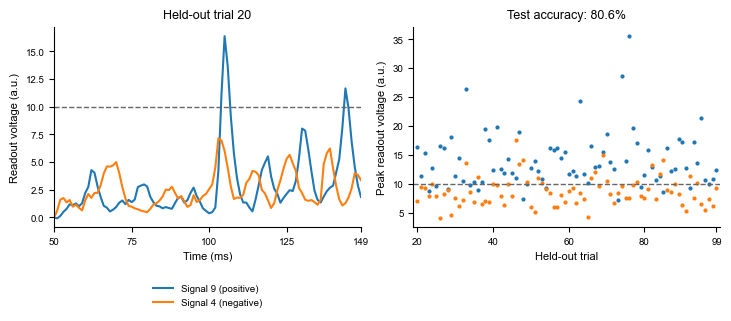

In [4]:
fig = build_figure(result)
save_figure(fig, 'Tempotron_cri_demo')
plt.close(fig)
fig

## 4. Return the learned model and predictions

Rows in `peak_voltage` correspond to signals 9 and 4; columns correspond to trial IDs 20–99. Weight entries 0–799 read region A and 800–1599 read region B, in the order recorded by `selected_neuron_ids`. The original error formula uses strict inequalities; `threshold_ties` reports any equality cases explicitly.

In [5]:
{key: value.shape for key, value in result.items()}

{'accuracy': (),
 'weights': (1600,),
 'updates': (),
 'peak_times_signal_positive': (80,),
 'peak_voltage': (2, 80),
 'example_voltage': (2, 100),
 'selected_neuron_ids': (2, 800),
 'signals': (2,),
 'threshold': (),
 'time_ms': (100,),
 'test_trial_ids': (80,),
 'threshold_ties': ()}